# Olist E-Commerce: Exploratory Data Analysis

**Project:** E-Commerce Performance & Customer Insights  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (~100K orders, 2016-2018)  
**Notebook scope:**
1. Data loading and cleaning
2. Exploratory data analysis (EDA)
3. Delivery delay vs. review score correlation
4. RFM score distribution visualization
5. Export clean dataset for Power BI

> Note: This is a real but anonymized public dataset. Findings are for skill demonstration, not operational conclusions.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Paths
DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../data')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
# Load all tables
orders       = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv')
order_items  = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')
order_pays   = pd.read_csv(DATA_DIR / 'olist_order_payments_dataset.csv')
reviews      = pd.read_csv(DATA_DIR / 'olist_order_reviews_dataset.csv')
customers    = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
products     = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
sellers      = pd.read_csv(DATA_DIR / 'olist_sellers_dataset.csv')
cat_trans    = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')

print('Rows loaded:')
for name, df in [
    ('orders', orders), ('order_items', order_items), ('order_pays', order_pays),
    ('reviews', reviews), ('customers', customers), ('products', products),
]:
    print(f'  {name:15s}: {len(df):>7,}')

Rows loaded:
  orders         :  99,441
  order_items    : 112,650
  order_pays     : 103,886
  reviews        :  99,224
  customers      :  99,441
  products       :  32,951


## 2. Clean & Parse Dates

In [3]:
# Parse all datetime columns in orders
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Parse review timestamps
reviews['review_creation_date']    = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

print('Date columns parsed.')
orders[date_cols].dtypes

Date columns parsed.


order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [4]:
# Check nulls in orders
null_summary = orders.isnull().sum()
null_summary[null_summary > 0]

order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

In [5]:
# Filter to delivered orders only for delivery analysis
# (non-delivered orders won't have actual delivery dates)
delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f'Total orders:    {len(orders):,}')
print(f'Delivered orders: {len(delivered):,}')
print(f'Other statuses:  {orders["order_status"].value_counts().to_dict()}')

Total orders:    99,441
Delivered orders: 96,478
Other statuses:  {'delivered': 96478, 'shipped': 1107, 'canceled': 625, 'unavailable': 609, 'invoiced': 314, 'processing': 301, 'created': 5, 'approved': 2}


In [6]:
# Deduplicate reviews -- order_reviews has ~547 duplicate reviews per SQL analysis
# Keep one review per order_id (highest review_id = most recent)
reviews_deduped = (
    reviews
    .sort_values('review_answer_timestamp')
    .drop_duplicates(subset='order_id', keep='last')
)
print(f'Reviews before dedup: {len(reviews):,}')
print(f'Reviews after dedup:  {len(reviews_deduped):,}')

Reviews before dedup: 99,224
Reviews after dedup:  98,673


## 3. Exploratory Data Analysis

### 3a. Monthly Revenue & Order Volume

In [7]:
# Merge orders with payments to get revenue
# Sum payments per order (some orders have multiple payment rows)
order_revenue = (
    order_pays
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index()
    .rename(columns={'payment_value': 'revenue'})
)

orders_rev = orders.merge(order_revenue, on='order_id', how='left')
orders_rev['order_month'] = orders_rev['order_purchase_timestamp'].dt.to_period('M')

monthly = (
    orders_rev
    .groupby('order_month')
    .agg(order_count=('order_id', 'count'), total_revenue=('revenue', 'sum'))
    .reset_index()
)
monthly['order_month_str'] = monthly['order_month'].astype(str)

monthly.tail(10)

,order_month,order_count,total_revenue,order_month_str
15,2018-01,7269,1115004.18,2018-01
16,2018-02,6728,992463.34,2018-02
17,2018-03,7211,1159652.12,2018-03
18,2018-04,6939,1160785.48,2018-04
19,2018-05,6873,1153982.15,2018-05
20,2018-06,6167,1023880.50,2018-06
21,2018-07,6292,1066540.75,2018-07
22,2018-08,6512,1022425.32,2018-08
23,2018-09,16,4439.54,2018-09
24,2018-10,4,589.67,2018-10


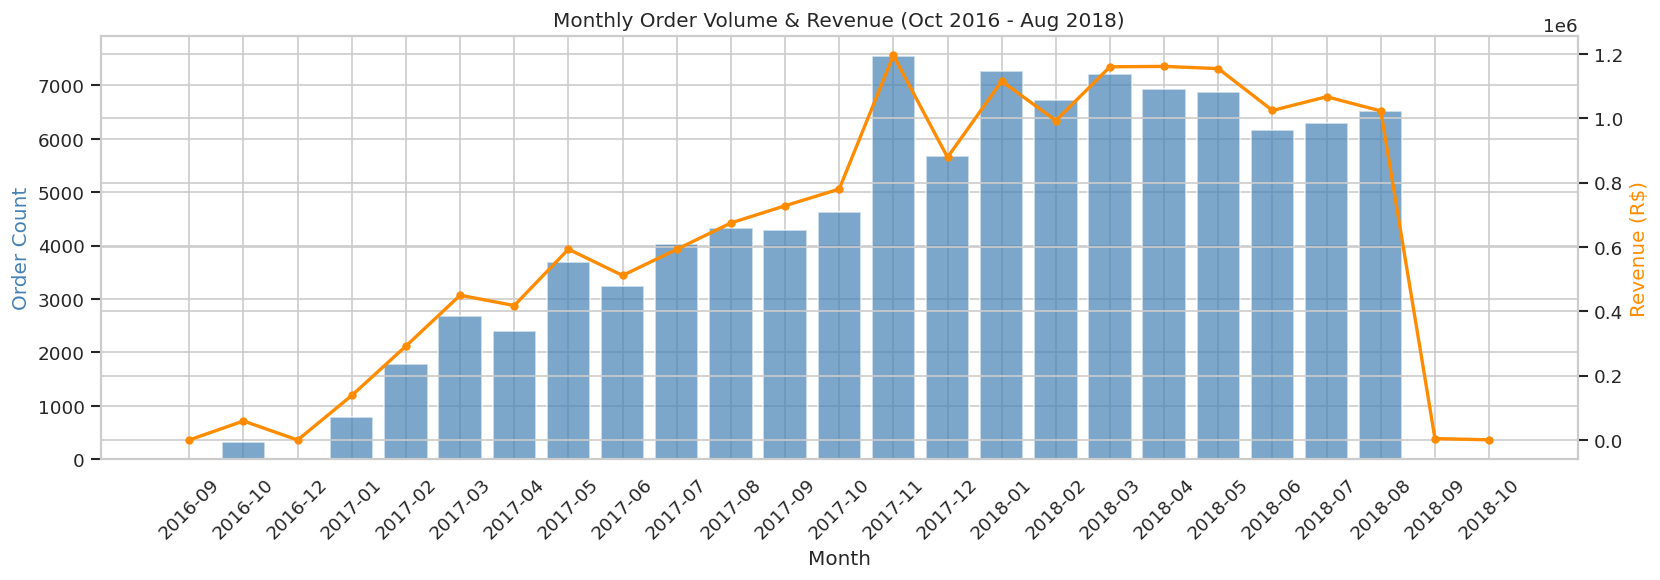

In [8]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(monthly['order_month_str'], monthly['order_count'], color='steelblue', alpha=0.7, label='Order Count')
ax1.set_xlabel('Month')
ax1.set_ylabel('Order Count', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly['order_month_str'], monthly['total_revenue'], color='darkorange', linewidth=2, marker='o', markersize=4, label='Revenue (R$)')
ax2.set_ylabel('Revenue (R$)', color='darkorange')

plt.title('Monthly Order Volume & Revenue (Oct 2016 - Aug 2018)')
fig.tight_layout()
plt.savefig('../data/monthly_revenue_orders.png', bbox_inches='tight')
plt.show()

### 3b. Review Score Distribution

Mean review score: 4.09


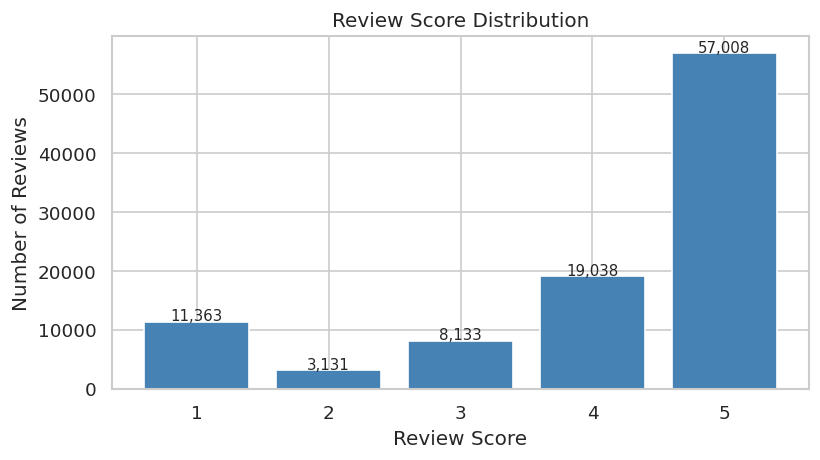

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
score_counts = reviews_deduped['review_score'].value_counts().sort_index()
ax.bar(score_counts.index, score_counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Review Score')
ax.set_ylabel('Number of Reviews')
ax.set_title('Review Score Distribution')
for i, v in enumerate(score_counts.values):
    ax.text(score_counts.index[i], v + 200, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/review_score_distribution.png', bbox_inches='tight')
plt.show()

print(f'Mean review score: {reviews_deduped["review_score"].mean():.2f}')

## 4. Delivery Delay vs. Review Score Correlation

In [10]:
# Calculate delivery delay: actual - estimated (positive = late)
delivered['delay_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']
).dt.total_seconds() / 86400

# Merge with deduplicated reviews
delay_review = delivered[['order_id', 'delay_days']].merge(
    reviews_deduped[['order_id', 'review_score']], on='order_id', how='inner'
)

print(f'Orders with both delivery and review data: {len(delay_review):,}')
print(f'\nDelay stats (days):')
print(delay_review['delay_days'].describe().round(2))

Orders with both delivery and review data: 95,832

Delay stats (days):
count    95824.00
mean       -11.22
std         10.11
min       -146.02
25%        -16.25
50%        -11.97
75%         -6.41
max        188.98
Name: delay_days, dtype: float64


In [11]:
# Tag on-time vs late
delay_review['delivery_status'] = delay_review['delay_days'].apply(
    lambda x: 'Late' if x > 0 else 'On Time'
)

avg_by_status = delay_review.groupby('delivery_status')['review_score'].mean().round(2)
print('Average review score by delivery status:')
print(avg_by_status)
print(f'\nScore gap: {avg_by_status["On Time"] - avg_by_status["Late"]:.2f} points')

Average review score by delivery status:
delivery_status
Late       2.57
On Time    4.29
Name: review_score, dtype: float64

Score gap: 1.72 points


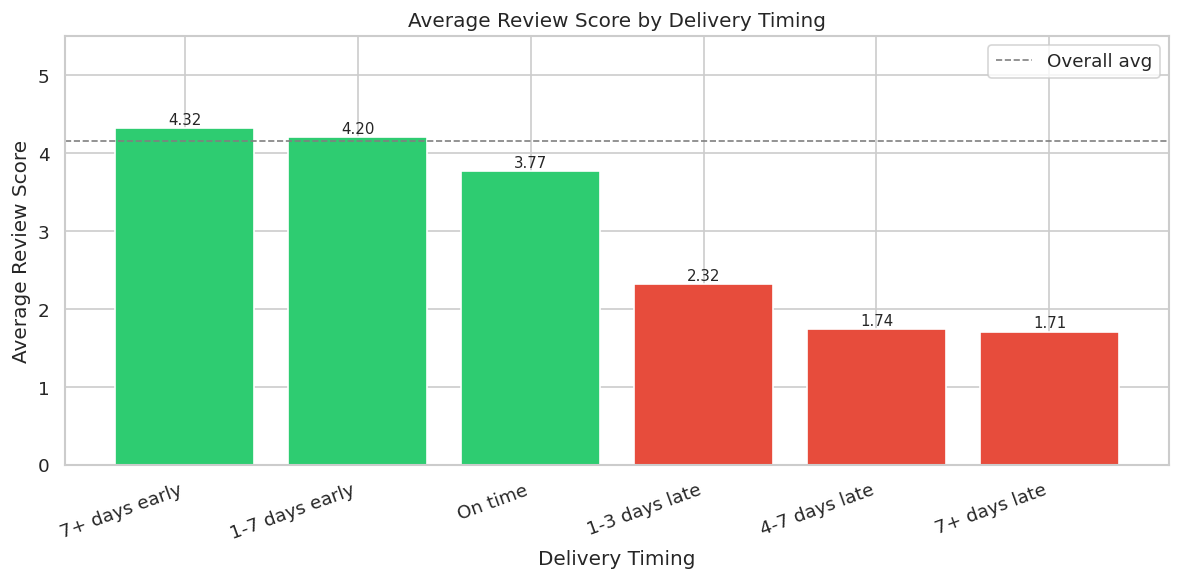

In [12]:
# Bin delay into buckets for a cleaner chart
bins = [-float('inf'), -7, 0, 3, 7, 14, float('inf')]
labels = ['7+ days early', '1-7 days early', 'On time', '1-3 days late', '4-7 days late', '7+ days late']
delay_review['delay_bucket'] = pd.cut(delay_review['delay_days'], bins=bins, labels=labels)

bucket_avg = delay_review.groupby('delay_bucket', observed=True)['review_score'].mean().reset_index()
bucket_avg.columns = ['delay_bucket', 'avg_review_score']

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if 'early' in str(b) or b == 'On time' else '#e74c3c'
          for b in bucket_avg['delay_bucket']]
bars = ax.bar(bucket_avg['delay_bucket'].astype(str), bucket_avg['avg_review_score'], color=colors, edgecolor='white')
ax.set_ylim(0, 5.5)
ax.set_xlabel('Delivery Timing')
ax.set_ylabel('Average Review Score')
ax.set_title('Average Review Score by Delivery Timing')
ax.axhline(y=delay_review['review_score'].mean(), color='gray', linestyle='--', linewidth=1, label='Overall avg')
ax.legend()
for bar, val in zip(bars, bucket_avg['avg_review_score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}', ha='center', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../data/delay_vs_review.png', bbox_inches='tight')
plt.show()

In [13]:
# Pearson correlation: delay days vs review score
corr = delay_review['delay_days'].corr(delay_review['review_score'])
print(f'Pearson correlation (delay_days vs review_score): {corr:.4f}')
print('Interpretation: negative value means more delay = lower score')

Pearson correlation (delay_days vs review_score): -0.2670
Interpretation: negative value means more delay = lower score


## 5. RFM Score Distribution Visualization

In [14]:
# Build RFM from scratch in Python to match the SQL analysis
# Use customer_unique_id from customers table for true per-customer counts

# Step 1: merge orders -> customers -> payments
orders_customers = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
orders_customers = orders_customers.merge(order_revenue, on='order_id', how='left')

# Use only delivered orders for RFM
rfm_base = orders_customers[orders_customers['order_status'] == 'delivered'].copy()

# Reference date: day after last order in dataset
reference_date = rfm_base['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Reference date for recency: {reference_date.date()}')

Reference date for recency: 2018-08-30


In [15]:
# Step 2: calculate R, F, M per customer
rfm = rfm_base.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'count'),
    monetary=('revenue', 'sum')
).reset_index()

# Step 3: score into quartiles (1-4) matching SQL NTILE(4) logic
# Lower recency days = more recent = score 4 (best)
rfm['r_score'] = pd.qcut(rfm['recency'], q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'], q=4, labels=[1, 2, 3, 4]).astype(int)

rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

# Step 4: segment labels matching SQL CASE WHEN logic exactly
def segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r == 4 and f >= 3 and m >= 3:
        return 'Champions'
    elif f >= 3 and m >= 3:
        return 'Loyal'
    elif r >= 3 and f <= 2:
        return 'Promising'
    elif r + f + m >= 7:
        return 'Needs Attention'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(segment, axis=1)

print(rfm['segment'].value_counts())
print(f'\nTotal customers: {len(rfm):,}')

segment
Lost               23651
Promising          23356
Needs Attention    22516
Loyal              17706
Champions           6129
Name: count, dtype: int64

Total customers: 93,358


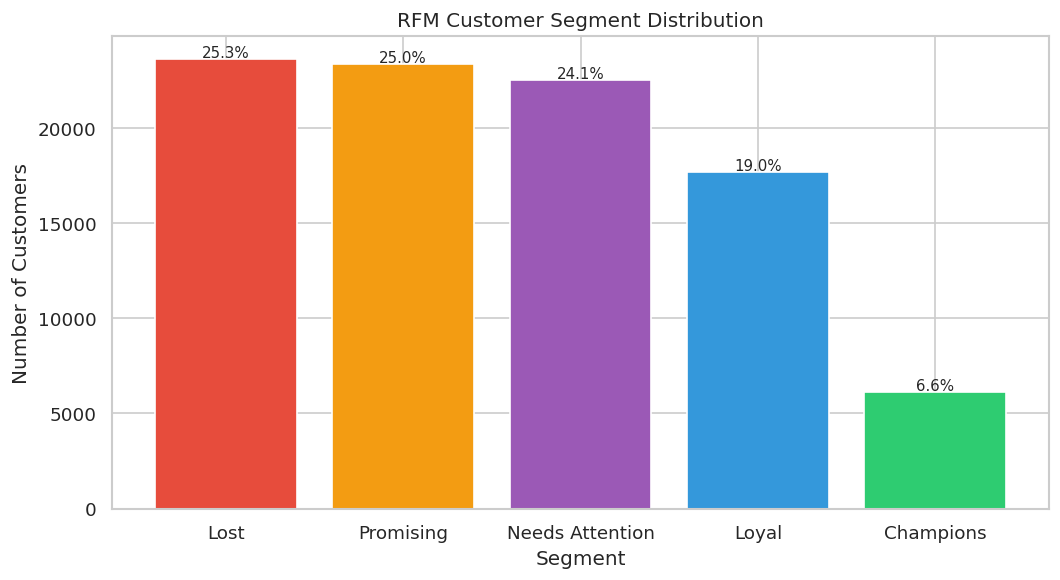

In [16]:
# Segment distribution bar chart
seg_counts = rfm['segment'].value_counts()
seg_pct = (seg_counts / len(rfm) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
palette = {
    'Champions': '#2ecc71',
    'Loyal': '#3498db',
    'Promising': '#f39c12',
    'Needs Attention': '#9b59b6',
    'Lost': '#e74c3c'
}
colors = [palette.get(s, '#95a5a6') for s in seg_counts.index]
bars = ax.bar(seg_counts.index, seg_counts.values, color=colors, edgecolor='white')
ax.set_xlabel('Segment')
ax.set_ylabel('Number of Customers')
ax.set_title('RFM Customer Segment Distribution')
for bar, pct in zip(bars, seg_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{pct}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/rfm_segment_distribution.png', bbox_inches='tight')
plt.show()

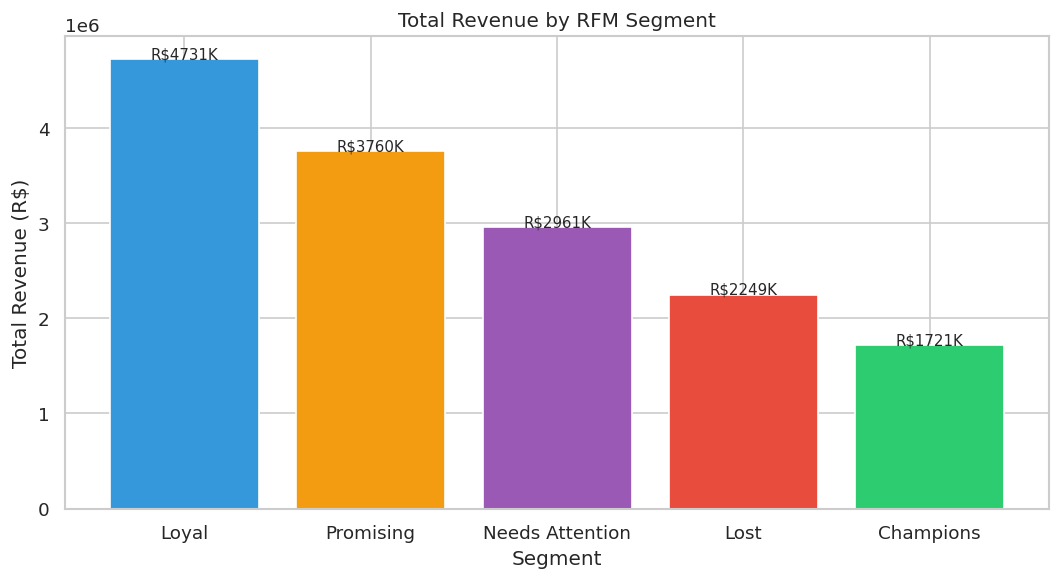

In [17]:
# Revenue by segment
seg_revenue = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [palette.get(s, '#95a5a6') for s in seg_revenue.index]
bars = ax.bar(seg_revenue.index, seg_revenue.values, color=colors, edgecolor='white')
ax.set_xlabel('Segment')
ax.set_ylabel('Total Revenue (R$)')
ax.set_title('Total Revenue by RFM Segment')
for bar, val in zip(bars, seg_revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'R${val/1000:.0f}K', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/rfm_revenue_by_segment.png', bbox_inches='tight')
plt.show()

## 6. Export Clean Dataset for Power BI

In [18]:
# Build master fact table: one row per order with key fields
# orders + customers + revenue + reviews + delivery delay

# Add English category names
products_eng = products.merge(cat_trans, on='product_category_name', how='left')

# Aggregate items per order: total items, dominant category
items_agg = (
    order_items
    .merge(products_eng[['product_id', 'product_category_name_english']], on='product_id', how='left')
    .groupby('order_id')
    .agg(
        item_count=('order_item_id', 'count'),
        primary_category=('product_category_name_english', lambda x: x.mode()[0] if not x.mode().empty else None)
    )
    .reset_index()
)

# Build master table
master = (
    orders
    .merge(customers[['customer_id', 'customer_unique_id', 'customer_state']], on='customer_id', how='left')
    .merge(order_revenue, on='order_id', how='left')
    .merge(reviews_deduped[['order_id', 'review_score']], on='order_id', how='left')
    .merge(items_agg, on='order_id', how='left')
)

# Add delay_days
master['delay_days'] = (
    master['order_delivered_customer_date'] - master['order_estimated_delivery_date']
).dt.total_seconds() / 86400

# Add RFM segment
master = master.merge(rfm[['customer_unique_id', 'rfm_score', 'segment']], on='customer_unique_id', how='left')

# Add month/year columns for Power BI time intelligence
master['order_year']  = master['order_purchase_timestamp'].dt.year
master['order_month'] = master['order_purchase_timestamp'].dt.month
master['order_yearmonth'] = master['order_purchase_timestamp'].dt.to_period('M').astype(str)

print(f'Master table shape: {master.shape}')
master.head(3)

Master table shape: (99441, 20)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,revenue,review_score,item_count,primary_category,delay_days,rfm_score,segment,order_year,order_month,order_yearmonth
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,38.71,4.0,1.0,housewares,-7.107488,8.0,Needs Attention,2017,10,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,141.46,4.0,1.0,perfumery,-5.355729,10.0,Champions,2018,7,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,179.12,5.0,1.0,auto,-17.245498,8.0,Promising,2018,8,2018-08


In [19]:
# Export
export_path = OUTPUT_DIR / 'olist_master_powerbi.csv'
master.to_csv(export_path, index=False)
print(f'Exported: {export_path}')
print(f'Shape: {master.shape}')
print(f'Columns: {list(master.columns)}')

Exported: ../data/olist_master_powerbi.csv
Shape: (99441, 20)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_state', 'revenue', 'review_score', 'item_count', 'primary_category', 'delay_days', 'rfm_score', 'segment', 'order_year', 'order_month', 'order_yearmonth']


## 7. Summary of Key Findings

| Finding | Value |
|---|---|
| Revenue growth (Oct 2016 to Nov 2017) | ~20x |
| Nov 2017 MoM spike (Black Friday) | +53% |
| On-time delivery rate | 91.9% |
| Avg review score: on-time vs late | 4.29 vs 2.57 (-1.72 pts) |
| Largest RFM segment | Promising (recent, low frequency) |
| Top revenue category | Health & Beauty (R$1.23M, 9.33% of total) |

**Biggest opportunity:** Promising and Lost segments represent customers who haven't returned. Converting even 10% to repeat buyers is the highest-leverage revenue lever.